# TP2 IDENTIFICATOION D'UN SYSTEME 

## 1.1 Méthode de strejc

La methode de strejc permet d'approcher le comptortement d'un systeme de fonction de tranfert connue par un systeme de fonction de transfert d'ordre N avec un retard pur ,tel que $T(P)=\frac{K*e^{-rp}}{(1+\tau*p)^n}$

Soit le système linéaire défini par la fonction de transfert suivante :
H(p)=$\frac{100}{p^3+10p^2+29p+20}$

la méthode de Strejc consite a approcher une fonction de transfert complexe H(p) par une fonction de transfert plus simple  T(p).
Donc identifier H(p) revient a retrouver les paramètres (n,$\tau$,r,K) de T(p) a partir de l'expression de H(p)
Pour cela je dois au prelable trouver la réponse impulsionnelle du système H(p).

### étape 1 : définir H(p) dans python a l'aide de la methode tf 

In [1]:
# install the control library if it isn't already available
%pip install control

import numpy as np
import matplotlib.pyplot as plt
import control as ct

num = [100]
deno = [1, 10, 29, 20]
H = ct.tf(num, deno)
print(H)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

            100
  ------------------------
  s^3 + 10 s^2 + 29 s + 20


### étape 2: a l’aide de l’instruction tf2zpk, déterminer et afficher les zéros, les pôles et le gain du système H(p) sous la forme H(p) = $K \frac{\prod_{i=1}^{m}(p - z_i)}{\prod_{j=1}^{n}(p - p_j)}$

La methode tf2zpk est une fonction de conversion du package control qui transforme une fonction de transfert du format tf (Transfer Function=H(p)=$\frac{100}{p^3+10p^2+29p+20}$) au format zpk (Zéros, Pôles, Gain) tel que  H(p) = $K \frac{\prod_{i=1}^{m}(p - z_i)}{\prod_{j=1}^{n}(p - p_j)}$

In [ ]:
#il faut d'abord importer scipy pour pouvoir utiliser la methode tf2zpk
import scipy.signal as sig

num = [100]
deno = [1, 10, 29, 20]

z, p, k = sig.tf2zpk(num, deno)

print("poles :", p)
print("zeros :", z)
print("gain :", k)

poles : [-5. -4. -1.]
zeros : []
gain : 100.0


### étape3 : Tracer la réponse indicielle du système.

c'est la réponse ou comportement en sortie du systeme H(p) lorqu'il est soumis a une entré échelon 

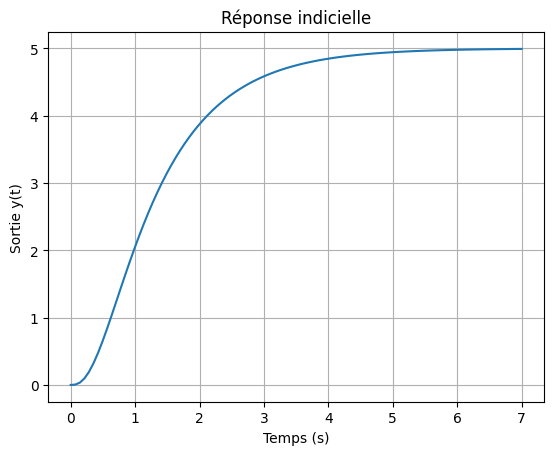

In [ ]:
import scipy.signal as sig
import matplotlib.pyplot as plt

# définition du système
num = [100]
den = [1, 10, 29, 20]

H = sig.TransferFunction(num, den)

# réponse indicielle
# la fonction step retourne deux tableaux : le temps et la réponse indicielle correspondante
# t1 est un tableau de temps, Yind est un tableau de la réponse indicielle correspondante
#Yind=Yindicielle 
t1, Yind = sig.step(H)

# affichage
plt.figure()
plt.plot(t1, Yind)
plt.grid()
plt.xlabel("Temps (s)")
plt.ylabel("Sortie y(t)")
plt.title("Réponse indicielle")
plt.show()

### étape4 : Tracer la réponse impulsionnelle du système en utilisant l’instruction signal.impulse()


c'est la reponse ou comportement du systeme H(p) a un signal impulsionel comme l'impuslsion de dirac

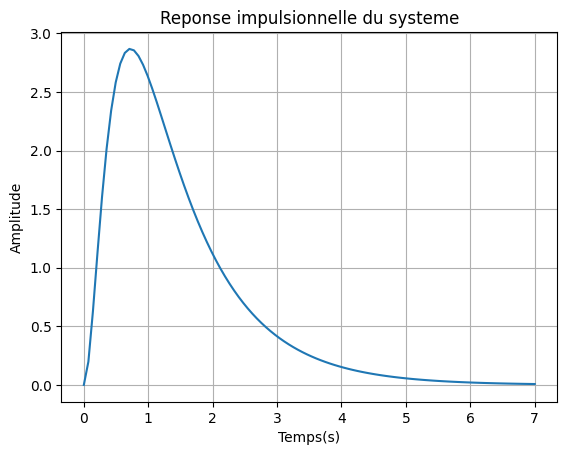

In [14]:
import scipy.signal as sig
import matplotlib.pyplot as plt

# définition du système
num = [100]
den = [1, 10, 29, 20]

H = sig.TransferFunction(num, den)



t2,Yimp = sig.impulse(H)
plt.figure()
plt.plot(t2.T,Yimp.T)
plt.title('Reponse impulsionnelle du systeme')
plt.ylabel('Amplitude')
plt.xlabel('Temps(s)')
plt.grid()
plt.show()


### déterminer l’abscisse du point d’inflexion i de cette réponse.

Amplitude d'inflexion : 2.8672893791915013
Temps d'inflexion : 0.7070707070707072 sec


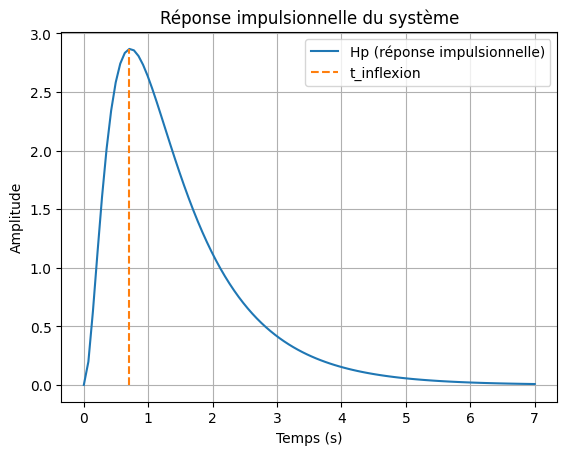

In [ ]:
import scipy.signal as sig
import matplotlib.pyplot as plt
import numpy as np

# définition du système
num = [100]
den = [1, 10, 29, 20]

H = sig.TransferFunction(num, den)

# réponse impulsionnelle
t2, Yimp = sig.impulse(H)

# indice du maximum
i = np.argmax(Yimp)
t_inf = t2[i]

print("Amplitude d'inflexion :", Yimp.max())
print("Temps d'inflexion :", t_inf, "sec")

plt.figure()

# courbe principale
plt.plot(t2, Yimp, label="Hp (réponse impulsionnelle)")

# ligne verticale au temps d'inflexion
plt.plot([t_inf, t_inf], [0, Yimp.max()],
         linestyle="--",
         label="t_inflexion")

# habillage
plt.title("Réponse impulsionnelle du système")
plt.ylabel("Amplitude")
plt.xlabel("Temps (s)")
plt.grid(True)
plt.legend()

# affichage FINAL
plt.show()

### Déterminer l’équation de la tangente au point i et tracer la droite sur la réponse indicielle.


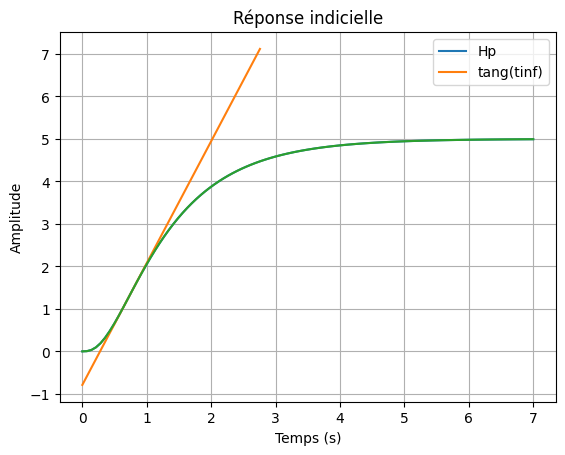

In [ ]:

import scipy.signal as sig
import matplotlib.pyplot as plt

# définition du système
num = [100]
den = [1, 10, 29, 20]

H = sig.TransferFunction(num, den)

# réponse indicielle
# la fonction step retourne deux tableaux : le temps et la réponse indicielle correspondante
# t1 est un tableau de temps, Yind est un tableau de la réponse indicielle correspondante
#Yind=Yindicielle 
t1, Yind = sig.step(H)
def get_index(value,l,e):
    for i in range(len(l)):
        if abs(l[i]-value)<=e:
            break
    return i

#5 Determiner l'equation de la tagente au point i 
def tan_gen(a,b,x,xi):
    y = []
    for i in x:
        y.append(a*(i-xi)+b)
    return y


i = get_index(t_inf, t1.T,0)
a,b,x,xi = Yimp.max(), Yind.T[i], t1.T[:40], t_inf
d = tan_gen(a,b,x,xi)

plt.plot(t1.T,Yind.T,t1.T[:40],d)
plt.legend(["Hp","tang(tinf)"])
plt.title('Reponse indicielle du systeme')
plt.ylabel('Amplitude')

# affichage

plt.plot(t1, Yind)
plt.grid()
plt.xlabel("Temps (s)")

plt.title("Réponse indicielle")
plt.show()

### Déterminer les valeurs de Strejc (n, τ et r) pour identifier le système

In [30]:
i = get_index(Yind.max(), d,0.1)
tmax = t1.T[i]
i = get_index(0, d,0.1)
tmin = t1.T[i]
Tu = tmin
Ta = tmax-tmin
print("Ta :", Ta,"sec")
print("Tu :", Tu,"sec")
print("Rapport Tu/Ta :",Tu/Ta)
n = 2
Ta_Taux = 2.7183
Tu2_Taux = 0.2817
taux = Ta/Ta_Taux
Tu2 = taux*Tu2_Taux
r = Tu-Tu2
print("taux :",taux,"sec")
print("r :",r,"sec")
print("n :",n)

Ta : 1.7676767676767682 sec
Tu : 0.2828282828282829 sec
Rapport Tu/Ta : 0.15999999999999998
taux : 0.6502875943335056 sec
r : 0.09964226750453434 sec
n : 2


### calculer T(p) Voir en annexe le rappel sur la méthode de Strejc

Pour résumer, la méthode d’identification de strecjc à partir de la réponse indicielle du système
s’appuie sur les étapes suivantes :
1. On recherche le point d’inflexion sur le relevé de la réponse indicielle.
2. On trace la tangente à la courbe en ce point.
3. On relève les valeurs Tu et Ta pour établir le rapport $\frac{Tu}{Ta}$
4. Dans le tableau, on détermine l’ordre n du système en fonction du rapport calculé
$\frac{Tu}{Ta}$ . Il est rare que la valeur du rapport $\frac{Tu}{Ta}$donne une valeur exacte du tableau.
On prend alors la valeur immédiatement inférieure dans le tableau.
5. On calcule τ avec le rapport $\frac{Ta}{\Tau}$
6. Comme le rapport $\frac{Tu}{Ta}$ n’est pas dans le tableau, on calcule un nouveau Tu’ avec le
rapport $\frac{Tu}{Ta}$ du tableau et le retard r est égal à Tu - Tu’.

In [40]:
num_pade, den_pade = ct.pade(r,10)
sys_approx = ((k),(taux,1))
Tp1 = ct.tf((k),(taux,1))
Tp2 = ct.tf((1),(taux,1))
Tp3 = ct.tf(num_pade,den_pade)
Tp = ct.series(Tp1, Tp2, Tp3)
print("Approximation :\n"," 5 e^(-0.0996 s)\n--------------------\n  (0.650 s + 1)^2")
Yind2,t3 = ct.step_response(Tp, T=t1.T)
Yind3,t4 = ct.step_response(H, T=t1.T)
plt.figure()
plt.plot(t4.T,Yind3.T)
plt.plot(t3.T,Yind2.T)
plt.legend(["Hp","Tp"])
plt.title('Reponse indicielle du systeme (Strejc)')
plt.ylabel('Amplitude')
plt.xlabel('Temps(s)')
plt.grid(True)
plt.show()

Approximation :
  5 e^(-0.0996 s)
--------------------
  (0.650 s + 1)^2


AttributeError: 'TransferFunctionContinuous' object has no attribute 'ninputs'